<h1 style="text-align: center;">Session Tunes</h1>

## Dataset

Using the webscraper that I built in `session_tunes.py`, I compiled a dataset of tunes which is stored in the `tunes.json` file. As of the latest run, it contains data for approximately 22,000 tunes from [TheSession.org](https://thesession.org).

Each entry in the JSON file represents a single Irish tune from the website, and contains the following columns/variables:

| Variable | Description |
|---|---|
| `name` | The primary name for the tune on [TheSession.org](https://thesession.org). |
| `aliases` | Other names that the time is known |
| `type` | The Genre that the tune belongs to (reel, jig, hornpipe, etc.) |
| `tabs` | Number of sheet music submissions on the site for the tune |
| `recordings` | Number of times the tune is known to appear in a recorded album |
| `collections` | Number of tune collections the tune has been added to |
| `sets` | Number of sets the tune has been added to |
| `books` | Number of users who have added the tune to their personal tunebook |

## Data Exploration

In [1]:
import numpy as np
import pandas as pd
import session_tunes
import matplotlib.pyplot as plt

# Read in the tunes.json data
tunes = pd.read_json('tunes.json')
session_tunes.set_display_options()
tunes.head()

,name,aliases,type,set_pairings,tabs,recordings,collections,sets,books
1,Cooley’s,"Cooleys, Joe Coo...",reel,"[27, 118, 629, 7...",20,189,4,1206,5434.0
2,The Bucks Of Ora...,The Bucks Of Ara...,reel,"[116, 511, 86, 1...",19,201,7,231,2016.0
3,Boil The Breakfa...,"Peadar’s, Pedar’s.",reel,"[840, 514, 5195,...",7,50,3,52,392.0
4,The Belfast,"Great Eastern, G...",hornpipe,"[3250, 49, 83, 2...",12,57,7,90,641.0
5,The Blarney Pilgrim,Dean Lloyd’s Jig...,jig,"[9, 70, 19, 793,...",14,94,5,646,2845.0


### The `tabs` Variable

A *tab* (short for *tablature*) refers to written musical notation submitted by a user on [TheSession.org](https://thesession.org). A tune's page can have multiple tabs from different authors, each representing a slightly different arrangement.

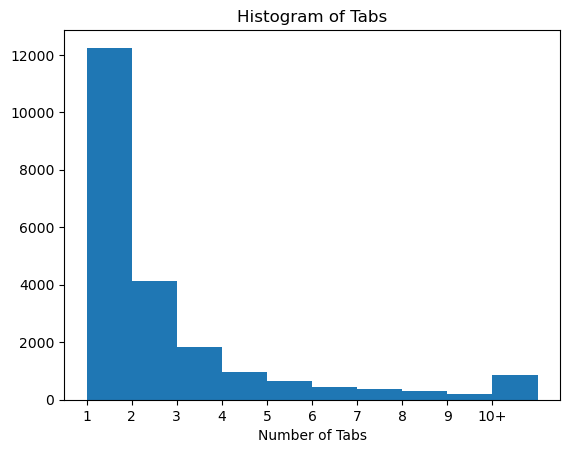

In [2]:
tab_bins = np.arange(1, 12, 1)
plt.hist([np.clip(tunes['tabs'], tab_bins[0], tab_bins[-1])], bins=tab_bins)
xlabels = [str(i) for i in tab_bins][:-1]
xlabels[-1] += "+"
plt.xticks(tab_bins[:-1], xlabels)
plt.xlabel("Number of Tabs")
plt.title("Histogram of Tabs")
plt.show()

The distribution of `tabs` is heavily right-skewed; most tunes have only a small number of tab submissions, with a long tail of tunes that have many.

In [3]:
def describe_variable(df_column):
    """Returns summary statistics for a pandas Series."""
    return (df_column.mean(), df_column.median(), list(df_column.mode())[0],
            df_column.min(), df_column.max(), df_column.var(), df_column.std())

def print_description(sum_stats, name):
    values = [round(float(s), 2) for s in sum_stats]
    labels = ["Mean", "Median", "Mode", "Minimum", "Maximum", "Variance", "Std Dev"]
    print(f'{"Summary: " + name:^38}')
    for label, val in zip(labels, values):
        print(f"{label:28}{val:10.2f}")

print_description(describe_variable(tunes['tabs']), "Tabs")

            Summary: Tabs             
Mean                              2.49
Median                            1.00
Mode                              1.00
Minimum                           0.00
Maximum                          33.00
Variance                          9.03
Std Dev                           3.01


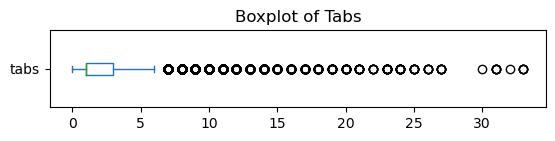

In [4]:
plt.figure().set_figheight(1)
tunes['tabs'].plot.box(vert=False)
plt.title('Boxplot of Tabs')
plt.show()

Tunes with more than 6 tabs are outliers, but they are meaningful to the analysis. More tabs may indicate a more popular tune.

### The `type` Variable

Tunes in traditional Irish music are classified by type, which determines their tempo and time signature. *Reels* are fast tunes in 4/4 time; *jigs* are in 6/8 and have a distinctive bouncy feel. The `type` variable records which genre each tune belongs to.

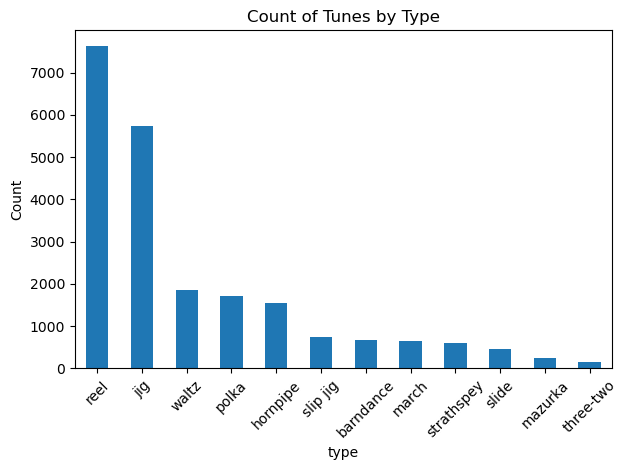

In [5]:
tunes['type'].value_counts().plot(kind='bar')
plt.xticks(rotation=45)
plt.title('Count of Tunes by Type')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

Reels and jigs together account for the majority of tunes in the dataset, which reflects their dominance in the traditional Irish repertoire.

### The `recordings` Variable

The `recordings` variable counts how many times a tune appears on a recorded album, as catalogued by [TheSession.org](https://thesession.org) users.

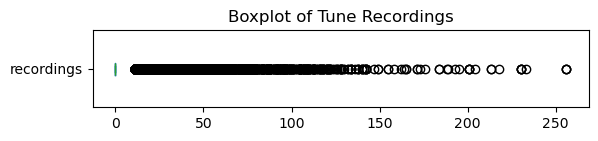

87.271% of tunes have no recordings.


In [6]:
plt.figure().set_figheight(1)
tunes['recordings'].plot.box(vert=False)
plt.title('Boxplot of Tune Recordings')
plt.show()

no_recordings = len(tunes[tunes['recordings'] == 0])
print(f"{round(no_recordings / len(tunes) * 100, 3)}% of tunes have no recordings.")

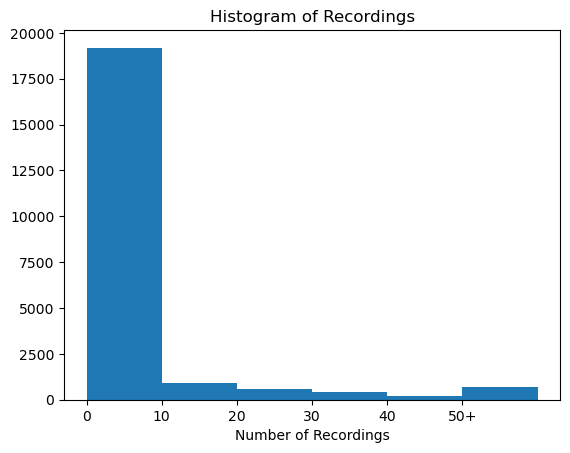

         Summary: Recordings          
Mean                              4.90
Median                            0.00
Mode                              0.00
Minimum                           0.00
Maximum                         256.00
Variance                        297.79
Std Dev                          17.26


In [7]:
rec_bins = np.arange(0, 70, 10)
plt.hist([np.clip(tunes['recordings'], rec_bins[0], rec_bins[-1])], bins=rec_bins)
xlabels = [str(i) for i in rec_bins][:-1]
xlabels[-1] += "+"
plt.xticks(rec_bins[:-1], xlabels)
plt.xlabel("Number of Recordings")
plt.title("Histogram of Recordings")
plt.show()

print_description(describe_variable(tunes['recordings']), "Recordings")

The vast majority of tunes have never been recorded. All tunes with at least one recording appear as outliers relative to the rest of the distribution. Recording a tune at all is relatively rare.

### The `sets` Variable

In traditional Irish music, tunes are rarely played in isolation. They are grouped into **sets**: sequences of two or more tunes played back to back. The `sets` variable counts how many sets on [TheSession.org](https://thesession.org) include a given tune.

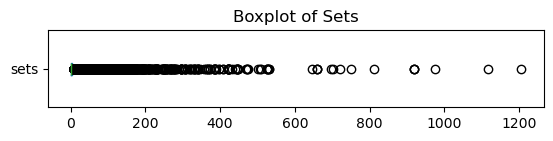

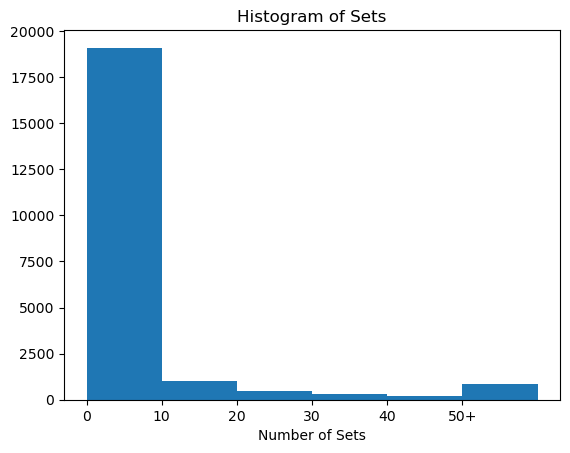

            Summary: Sets             
Mean                              8.65
Median                            0.00
Mode                              0.00
Minimum                           0.00
Maximum                        1206.00
Variance                       1557.46
Std Dev                          39.46


In [8]:
plt.figure().set_figheight(1)
tunes['sets'].plot.box(vert=False)
plt.title('Boxplot of Sets')
plt.show()

set_bins = np.arange(0, 70, 10)
plt.hist([np.clip(tunes['sets'], set_bins[0], set_bins[-1])], bins=set_bins)
xlabels = [str(i) for i in set_bins][:-1]
xlabels[-1] += "+"
plt.xticks(set_bins[:-1], xlabels)
plt.xlabel("Number of Sets")
plt.title("Histogram of Sets")
plt.show()

print_description(describe_variable(tunes['sets']), "Sets")

### The `books` Variable

[TheSession.org](https://thesession.org) users can save tunes to a personal **tunebook** to track tunes they know or are learning. The `books` variable counts how many users have saved a given tune, making it a useful proxy for overall tune popularity.

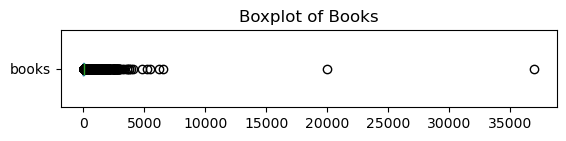

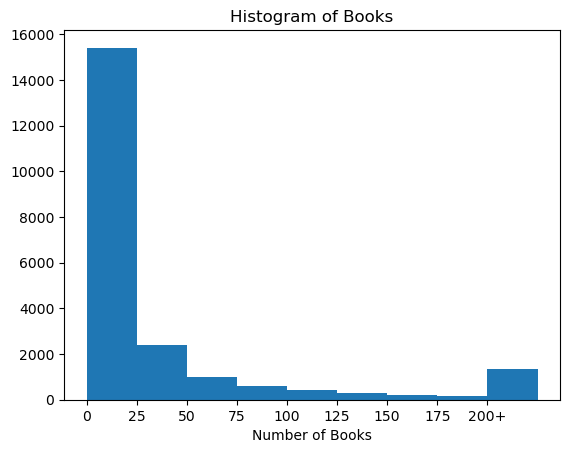

            Summary: Books            
Mean                             61.84
Median                           11.00
Mode                              3.00
Minimum                           0.00
Maximum                       37000.00
Variance                     126192.50
Std Dev                         355.24


In [9]:
plt.figure().set_figheight(1)
tunes['books'].plot.box(vert=False)
plt.title("Boxplot of Books")
plt.show()

book_bins = np.arange(0, 250, 25)
plt.hist([np.clip(tunes['books'], book_bins[0], book_bins[-1])], bins=book_bins)
xlabels = [str(i) for i in book_bins][:-1]
xlabels[-1] += "+"
plt.xticks(book_bins[:-1], xlabels)
plt.xlabel("Number of Books")
plt.title("Histogram of Books")
plt.show()

print_description(describe_variable(tunes['books']), "Books")

In [10]:
# Identify extreme outliers
tunes[tunes['books'] > 15000]

,name,aliases,type,set_pairings,tabs,recordings,collections,sets,books
20000,"20,000 League",Captain Balinsky’s.,slip jig,None,1,0,0,0,20000.0
22445,"37,000 Feet",37000 Ft.,reel,None,1,0,0,0,37000.0


The outliers revealed a web-scraping error where the `books` variable was set to the integer portion of the tune `name`. I double checked the actual value of these manually on [TheSession.org](https://thesession.org) and changed their values manually.

In [11]:
# Recode scraping errors in the books column
tunes.loc[tunes['name'] == '20,000 League', 'books'] = 5
tunes.loc[tunes['name'] == '37,000 Feet', 'books'] = 4

## Correlation Analysis

#### Books vs. Sets

I now want to explore what makes a tune popular. Because the `books` variable is a reasonable proxy for popularity, I'll explore it's relationship with other variables in the dataset.

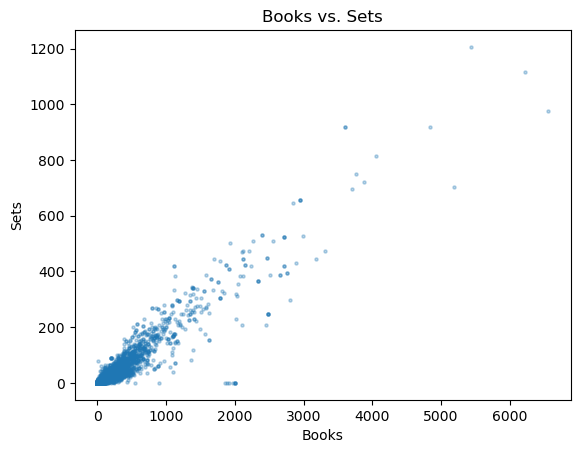

Correlation between Books and Sets
  Pearson:   0.94
  Spearman:  0.71


In [12]:
# Scatterplot: Books vs. Sets
plt.scatter(tunes['books'], tunes['sets'], alpha=0.3, s=5)
plt.xlabel("Books")
plt.ylabel("Sets")
plt.title("Books vs. Sets")
plt.show()

p_cor = tunes['books'].corr(tunes['sets'], method='pearson')
s_cor = tunes['books'].corr(tunes['sets'], method='spearman')
print("Correlation between Books and Sets")
print(f"  Pearson:   {round(p_cor, 2)}")
print(f"  Spearman:  {round(s_cor, 2)}")

The relationship between `books` and `sets` is strong and positive. The higher the `books` count, the more likely a tune is to appear in a large number of `sets`. 

#### Recordings vs. Tabs

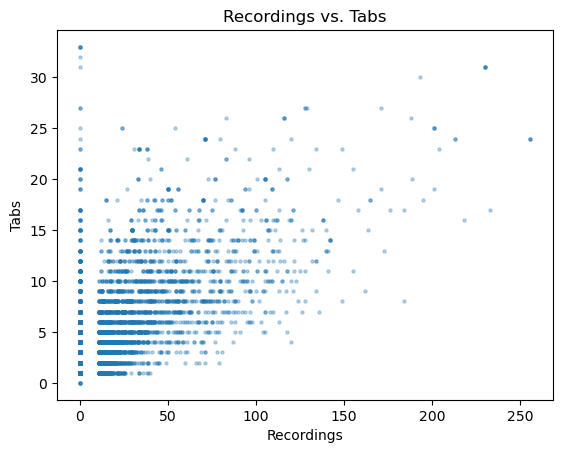

Correlation between Tabs and Recordings
  Pearson:   0.701
  Spearman:  0.535


In [13]:
# Scatterplot: Tabs vs. Recordings
plt.scatter(tunes['recordings'], tunes['tabs'], alpha=0.3, s=5)
plt.xlabel("Recordings")
plt.ylabel("Tabs")
plt.title("Recordings vs. Tabs")
plt.show()

p2_cor = tunes['tabs'].corr(tunes['recordings'], method='pearson')
s2_cor = tunes['tabs'].corr(tunes['recordings'], method='spearman')
print("Correlation between Tabs and Recordings")
print(f"  Pearson:   {round(p2_cor, 3)}")
print(f"  Spearman:  {round(s2_cor, 3)}")

The relationship between `tabs` and `recordings` is moderately positive. The more times sheet music `tabs` a tune has, the more likely it is to have a higher `recordings` count.

## Hypothesis Test

#### Do Jigs and Reels have more Tunebook Saves that other tune types?

The data already shows that tunes of `type="Jig"` and `type="Reel"` are the most common tune types on [TheSession.org](https://thesession.org). What I want to assess now is whether they also tend to be more popular than other tune types, as measured by the `books` variable.

I'll use a permutation test to evaluate if there is a statistically significant difference in the `books` counts between jigs/reels and other tune types.

In [14]:
# Adapted from Allen B. Downey's ThinkStats2
# https://github.com/AllenDowney/ThinkStats2
# MIT License

class DiffMeansPermute:
    """Permutation test for the difference in means between two groups."""

    def __init__(self, data):
        self.data = data
        self.actual = self.TestStatistic(data)

    def TestStatistic(self, data):
        group1, group2 = data
        return abs(group1.mean() - group2.mean())

    def PValue(self, iters=1000):
        group1, group2 = self.data
        pool = np.hstack((group1, group2))
        n = len(group1)
        count = 0
        for _ in range(iters):
            np.random.shuffle(pool)
            simulated_stat = self.TestStatistic((pool[:n], pool[n:]))
            if simulated_stat >= self.actual:
                count += 1
        return count / iters

In [15]:
def RunTests(tunes_df, iters=1000):
    """
    Tests whether jigs and reels have a significantly different mean
    books count compared to all other tune types.
    Returns the p-value of the permutation test.
    """
    jigs_and_reels = tunes_df[(tunes_df['type'] == 'jig') | (tunes_df['type'] == 'reel')]
    other_types = tunes_df[(tunes_df['type'] != 'jig') & (tunes_df['type'] != 'reel')]

    values = jigs_and_reels['books'].values, other_types['books'].values
    test = DiffMeansPermute(values)
    return test.PValue(iters=iters)

In [16]:
# Run tests on progressively smaller samples to assess stability
n = len(tunes)
results = [["Sample Size", "P-Value"]]

for _ in range(7):
    sample = tunes.sample(n, random_state=42)
    p = RunTests(sample)
    results.append([n, p])
    n //= 2

print(f"{'Sample Size':>12}{'P-Value':>16}")
print("-" * 28)
for r in results[1:]:
    print(f"{r[0]:>12}{r[1]:>16.4f}")

 Sample Size         P-Value
----------------------------
       21990          0.0000
       10995          0.0000
        5497          0.0000
        2748          0.0000
        1374          0.0000
         687          0.0000
         343          0.0000


The p-values are very low across all sample sizes. This is strong support for my hypothesis, and indicates that jigs and reels do indeed have (on average) higher `books` save counts than the other types of tunes. Since `books` is a proxy for popularity, this also suggests that jigs and reels are indeed more popular than other tune types.

## Regression Analysis

Next, I'm interested if we can predict how popular a tune will be (as measured by `books`) based on the number of `tabs` it has using a simple regression model.

In [17]:
import statsmodels.formula.api as smf

model = smf.ols('books ~ tabs', data=tunes)
results = model.fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  books   R-squared:                       0.410
Model:                            OLS   Adj. R-squared:                  0.410
Method:                 Least Squares   F-statistic:                 1.516e+04
Date:                Sun, 31 May 2026   Prob (F-statistic):               0.00
Time:                        11:58:31   Log-Likelihood:            -1.4251e+05
No. Observations:               21861   AIC:                         2.850e+05
Df Residuals:                   21859   BIC:                         2.850e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    -54.8537      1.446    -37.946      0.000     -57.687     -52.020
tabs          45.7941      0.372    123.138      0.000      45.065      46.523
==============================================================================
Omnibus:                    36379.998   Durbin-Watson:                   1.492
Prob(Omnibus):                  0.000   Jarque-Bera (JB):         51369478.147
Skew:                          11.054   Prob(JB):                         0.00
Kurtosis:                     239.447   Cond. No.                         5.21
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

The `tabs` variable explains approximately 41% of the variance in `books` (R² ≈ 0.41), with a statistically significant coefficient. Tunes with more sheet music submissions tend to have more tunebook saves. This makes sense, because if a tune is popular and played widely, it is more likely to have developed more variations and therefore would be likely to have more `tabs` documented for it.